In [14]:
import pandas as pd
df = pd.read_csv(r"C:\Users\J Sree Karthik\Data_Visualizations\data-viz-class-material\WHR2023.csv")

print("Original columns:", df.columns.tolist())

# Select correct columns explicitly
df_clean = df[[
    'Country name',
    'Ladder score',
    'Logged GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]].copy()

# Rename properly
df_clean.columns = [
    'Country',
    'Happiness_Score',
    'GDP',
    'Social_Support',
    'Life_Expectancy',
    'Freedom',
    'Generosity',
    'Corruption'
]

print(df_clean.head())

Original columns: ['Country name', 'Ladder score', 'Standard error of ladder score', 'upperwhisker', 'lowerwhisker', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Ladder score in Dystopia', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
       Country  Happiness_Score     GDP  Social_Support  Life_Expectancy  \
0      Finland            7.804  10.792           0.969           71.150   
1      Denmark            7.586  10.962           0.954           71.250   
2      Iceland            7.530  10.896           0.983           72.050   
3       Israel            7.473  10.639           0.943           72.697   
4  Netherlands            7.403  10.942           0.930           71.550   

   F

In [15]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\J Sree Karthik\Data_Visualizations\data-viz-class-material\WHR2023.csv")
print("Original columns:", df.columns.tolist())

df_subset = df.iloc[:, :9]  # Select only the first 9 columns
df_subset.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
                    'Life_Expectancy','Freedom','Generosity','Corruption']

print(f"Dataset: {len(df_subset)} countries, {len(df_subset.columns)} columns")
print(df_subset.head())

Original columns: ['Country name', 'Ladder score', 'Standard error of ladder score', 'upperwhisker', 'lowerwhisker', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Ladder score in Dystopia', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expectancy', 'Explained by: Freedom to make life choices', 'Explained by: Generosity', 'Explained by: Perceptions of corruption', 'Dystopia + residual']
Dataset: 137 countries, 9 columns
       Country  Region  Happiness_Score    GDP  Social_Support  \
0      Finland   7.804            0.036  7.875           7.733   
1      Denmark   7.586            0.041  7.667           7.506   
2      Iceland   7.530            0.049  7.625           7.434   
3       Israel   7.473            0.032  7.535           7.411   
4  Netherlands   7.403            0.029  7.460           7.346   

   Life_Expectancy  Freedom  G

# task1

In [16]:
!pip install plotly


import pandas as pd
import plotly.express as px
import plotly.graph_objects as go 
region_avg = region_avg.sort_values('Happiness_Score')

fig1 = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h'
)

fig1.update_xaxes(range=[0, region_avg['Happiness_Score'].max()])

fig1.update_layout(
    title="Western Europe Shows the Highest Happiness Levels Among Selected Regions",
    plot_bgcolor='white'
)

fig1.show()

# Task-2

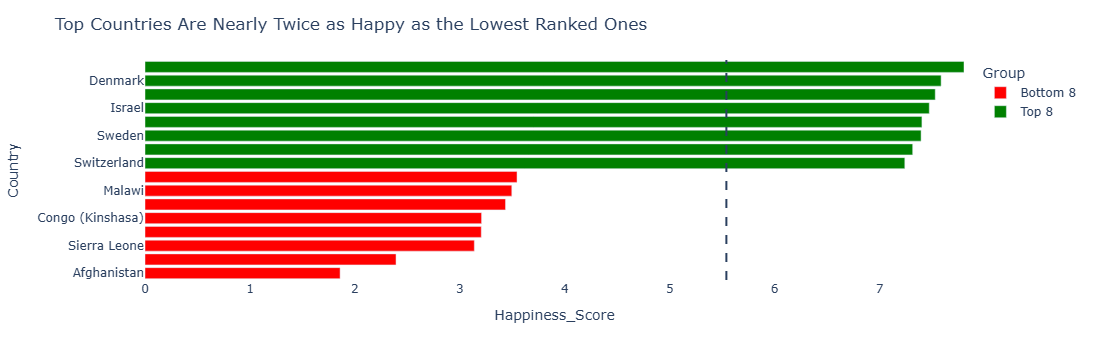

In [17]:
import pandas as pd
import plotly.express as px


top8 = df_clean.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'

bottom8 = df_clean.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8])
combined = combined.sort_values('Happiness_Score')


global_avg = df_clean['Happiness_Score'].mean()


fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    color_discrete_map={'Top 8': 'green', 'Bottom 8': 'red'}
)

fig.add_vline(x=global_avg, line_dash="dash")

fig.update_xaxes(range=[0, combined['Happiness_Score'].max()])

fig.update_layout(
    title="Top Countries Are Nearly Twice as Happy as the Lowest Ranked Ones",
    plot_bgcolor='white'
)

fig.show()

# task-3

               Region        GDP   Freedom
0           East Asia  10.349000  0.799333
1       Latin America   9.797000  0.826667
2          South Asia   8.661333  0.836000
3  Sub-Saharan Africa   7.818800  0.691600
4      Western Europe  10.853667  0.895556


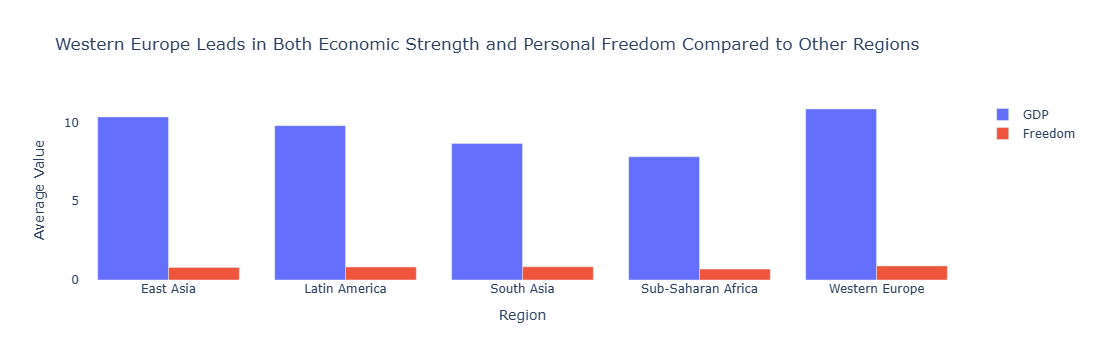

In [22]:
import pandas as pd
import plotly.graph_objects as go


if 'Region' not in df_clean.columns:
    region_map = {
        'Finland': 'Western Europe', 'Denmark': 'Western Europe', 'Iceland': 'Western Europe',
        'Netherlands': 'Western Europe', 'Sweden': 'Western Europe', 'Norway': 'Western Europe',
        'Germany': 'Western Europe', 'France': 'Western Europe', 'Spain': 'Western Europe',
        'India': 'South Asia', 'Pakistan': 'South Asia', 'Bangladesh': 'South Asia',
        'China': 'East Asia', 'Japan': 'East Asia', 'South Korea': 'East Asia',
        'Nigeria': 'Sub-Saharan Africa', 'Kenya': 'Sub-Saharan Africa', 'Ethiopia': 'Sub-Saharan Africa',
        'Congo (Kinshasa)': 'Sub-Saharan Africa', 'Sierra Leone': 'Sub-Saharan Africa',
        'Brazil': 'Latin America', 'Argentina': 'Latin America', 'Mexico': 'Latin America'
    }
    df_clean['Region'] = df_clean['Country'].map(region_map)
    df_clean = df_clean.dropna(subset=['Region'])


regions = ['Western Europe', 'Latin America', 'East Asia', 'Sub-Saharan Africa', 'South Asia']

df_clean.columns = df_clean.columns.str.strip()


required_cols = ['Region', 'GDP', 'Freedom']
for col in required_cols:
    if col not in df_clean.columns:
        raise ValueError(f"Column '{col}' not found in dataset")


subset = df_clean[df_clean['Region'].isin(regions)].copy()

subset[['GDP', 'Freedom']] = subset[['GDP', 'Freedom']].fillna(0)


grouped = subset.groupby('Region', as_index=False)[['GDP', 'Freedom']].mean()

print(grouped)

fig3 = go.Figure()

fig3.add_trace(go.Bar(
    x=grouped['Region'],
    y=grouped['GDP'],
    name='GDP'
))

fig3.add_trace(go.Bar(
    x=grouped['Region'],
    y=grouped['Freedom'],
    name='Freedom'
))

fig3.update_layout(
    barmode='group',
    title="Western Europe Leads in Both Economic Strength and Personal Freedom Compared to Other Regions",
    xaxis_title="Region",
    yaxis_title="Average Value",
    plot_bgcolor='white'
)

fig3.show()